In [1]:
import os
import sys

import pandas as pd
import json
import networkx as nx

sys.path.append('..')
from src.prompter import Prompter 

In [2]:
model_name = 'llama3'
prompter = Prompter(config_path="../config.yaml", model_type="llama4:16x17b")

src.prompter - INFO - Using yiyuan host: https://yiyuan.tsc.uc3m.es
src.prompter - INFO - Using yiyuan API with host: https://yiyuan.tsc.uc3m.es


Loaded config file ../config.yaml and section logger.
Logs will be saved in data/logs
Loaded config file ../config.yaml and section llm.


In [3]:
topic = "living lab"
n_keywords = 10

prompt_question = f'''
I will give you a topic. You need to provide the {n_keywords} most related keywords to this topic.
If there are fewer than {n_keywords} valid keywords available, output only the ones that exist. Never repeat a keyword for a given topic. All keywords must be unique.

CRITICAL RULE: None of the generated keywords may contain the topic word(s) itself. For example, if the topic is "cancer", keywords like "cancer treatment" or "lung cancer" are strictly forbidden. You must find distinct related terms (e.g., "oncology", "tumor", "chemotherapy").

For each keyword, assign a specificity score. This score must be a natural number between 1 and 10 inclusive.
You must also include the original topic itself in the output with a score of exactly 0.

Scoring Rubric Guidance:

Scores 8-10 (Highly Specific): Direct synonyms, highly technical sub-categories, or granular concepts exclusive to the topic (e.g., for "cancer", use "carcinoma", "chemotherapy").

Scores 4-7 (Moderately Related): Broadly related fields, symptoms, or associated concepts (e.g., for "cancer", use "oncology", "tumors").

Scores 1-3 (Loosely Related): High-level umbrella terms or vague associations (e.g., for "cancer", use "disease", "health").

Topic: {topic}

Return the result as a single, flat JSON dictionary where the keys are the words and the values are their integer scores. Order the keys in the output from the most specific (highest score) to the least specific (lowest score), with the topic itself at the very top. Use the following exact structure:

{{
"{topic}": 0,
"keyword1": score_1,
"keyword2": score_2,
"keyword3": score_3
}}

Do not output any markdown formatting (like ```json), code blocks, or extra text. Output ONLY the raw JSON dictionary.
'''


print("The Prompt:\n", prompt_question)


The Prompt:
 
I will give you a topic. You need to provide the 10 most related keywords to this topic.
If there are fewer than 10 valid keywords available, output only the ones that exist. Never repeat a keyword for a given topic. All keywords must be unique.

CRITICAL RULE: None of the generated keywords may contain the topic word(s) itself. For example, if the topic is "cancer", keywords like "cancer treatment" or "lung cancer" are strictly forbidden. You must find distinct related terms (e.g., "oncology", "tumor", "chemotherapy").

For each keyword, assign a specificity score. This score must be a natural number between 1 and 10 inclusive.
You must also include the original topic itself in the output with a score of exactly 0.

Scoring Rubric Guidance:

Scores 8-10 (Highly Specific): Direct synonyms, highly technical sub-categories, or granular concepts exclusive to the topic (e.g., for "cancer", use "carcinoma", "chemotherapy").

Scores 4-7 (Moderately Related): Broadly related fie

In [4]:
def get_keywords(topic, n_keywords, prompter):
    prompt_question = f'''
        I will give you a topic. You need to provide the {n_keywords} most related keywords to this topic.
        If there are fewer than {n_keywords} valid keywords available, output only the ones that exist. Never repeat a keyword for a given topic. All keywords must be unique.

        CRITICAL RULE: None of the generated keywords may contain the topic word(s) itself. For example, if the topic is "cancer", keywords like "cancer treatment" or "lung cancer" are strictly forbidden. You must find distinct related terms (e.g., "oncology", "tumor", "chemotherapy").

        For each keyword, assign a specificity score. This score must be a natural number between 1 and 10 inclusive.
        You must also include the original topic itself in the output with a score of exactly 0.

        Scoring Rubric Guidance:

        Scores 8-10 (Highly Specific): Direct synonyms, highly technical sub-categories, or granular concepts exclusive to the topic (e.g., for "cancer", use "carcinoma", "chemotherapy").

        Scores 4-7 (Moderately Related): Broadly related fields, symptoms, or associated concepts (e.g., for "cancer", use "oncology", "tumors").

        Scores 1-3 (Loosely Related): High-level umbrella terms or vague associations (e.g., for "cancer", use "disease", "health").

        Topic: {topic}

        Return the result as a single, flat JSON dictionary where the keys are the words and the values are their integer scores. Order the keys in the output from the most specific (highest score) to the least specific (lowest score), with the topic itself at the very top. Use the following exact structure:

        {{
        "{topic}": 0,
        "keyword1": score_1,
        "keyword2": score_2,
        "keyword3": score_3
        }}

        Do not output any markdown formatting (like ```json), code blocks, or extra text. Output ONLY the raw JSON dictionary.
        '''
    return prompter.prompt(prompt_question)[0]

In [5]:
response = get_keywords('living lab', 40, prompter)


'''
I will give you a topic. You need to provide the {n_keywords} most related keywords to this topic.
If there are fewer than {n_keywords} valid keywords available, output only the ones that exist. Never repeat a keyword for a given topic. All keywords must be unique.

CRITICAL RULE: None of the generated keywords may contain the topic word(s) itself. For example, if the topic is "cancer", keywords like "cancer treatment" or "lung cancer" are strictly forbidden. You must find distinct related terms (e.g., "oncology", "tumor", "chemotherapy").

For each keyword, assign a specificity score. This score must be a natural number between 1 and 10 inclusive (10 being extremely specific/synonymous, 1 being loosely related).
You must also include the original topic itself in the output with a score of exactly 0.

Topic: {topic}

Return the result as a single, flat JSON dictionary where the keys are the words and the values are their integer scores. Use the following exact structure:

{{
  "{topic}": 0,
  "keyword1": score_1,
  "keyword2": score_2,
  ...
  "keywordn": score_n
}}

Do not output any markdown formatting, code blocks, or extra text. Output ONLY the raw JSON dictionary.
'''


'''
I will give you a topic. You need to provide the {n_keywords} most related keywords to this topic.
If there are fewer than {n_keywords} valid keywords available, output only the ones that exist. Never repeat a keyword for a given topic. All keywords must be unique.

For each keyword, assign a specificity score. This score must be a natural number between 1 and 10 inclusive (10 being extremely specific, 1 being loosely related).
You must also include the original topic itself in the output with a score of exactly 0.

Topic: {topic}

Return the result as a single, flat JSON dictionary where the keys are the words and the values are their integer scores. Use the following exact structure:

{{
  "{topic}": 0,
  "keyword1": score_1,
  "keyword2": score_2,
  ...
  "keywordn": score_n
}}

Do not output any markdown formatting, code blocks, or extra text. Output ONLY the raw JSON dictionary.
'''

'''
I will give you a topic. You need to provide the {n_keywords} most related keywords to this topic.
If there are fewer than {n_keywords} valid keywords available, output only the ones that exist. Never repeat a keyword for a given topic. All keywords must be unique.

CRITICAL RULE: None of the generated keywords may contain the topic word(s) itself. For example, if the topic is "cancer", keywords like "cancer treatment" or "lung cancer" are strictly forbidden. You must find distinct related terms (e.g., "oncology", "tumor", "chemotherapy").

For each keyword, assign a specificity score. This score must be a natural number between 1 and 10 inclusive (10 being extremely specific, 1 being loosely related).
You must also include the original topic itself in the output with a score of exactly 0.

Topic: {topic}

Return the result as a single, flat JSON dictionary where the keys are the words and the values are their integer scores. Use the following exact structure:

{{
  "{topic}": 0,
  "keyword1": score_1,
  "keyword2": score_2,
  ...
  "keywordn": score_n
}}

Do not output any markdown formatting, code blocks, or extra text. Output ONLY the raw JSON dictionary.
'''



In [ ]:
#response = prompter.prompt(prompt_question)[0]

In [6]:
response

'{\n"living lab": 0,\n"co-creation": 9,\n"user-centered design": 9,\n"experimental urban planning": 9,\n"participatory research": 9,\n"collaborative innovation": 9,\n"living labs": 9,\n"testbeds": 8,\n"urban planning": 8,\n"sustainability": 8,\n"innovation hubs": 8,\n"co-design": 8,\n"prototyping": 8,\n"experimental design": 8,\n"user engagement": 8,\n"citizen participation": 8,\n"open innovation": 8,\n"design thinking": 7,\n"urban development": 7,\n"community engagement": 7,\n"participatory governance": 7,\n"social innovation": 7,\n"collaborative problem-solving": 7,\n"creative problem-solving": 7,\n"experimental learning": 7,\n"research and development": 7,\n"product development": 7,\n"service design": 7,\n"experience design": 7,\n"human-centered design": 7,\n"design research": 7,\n"innovation ecosystems": 6,\n"entrepreneurial ecosystems": 6,\n"startup incubators": 6,\n"accelerators": 6,\n"innovation districts": 6,\n"creative industries": 6,\n"knowledge transfer": 6,\n"technology tra

In [7]:
def extract_dictionary(response):
    clean_string = response.strip()
    if clean_string.startswith("```json"):
        clean_string = clean_string[7:]  
    elif clean_string.startswith("```"):
        clean_string = clean_string[3:]  
        
    if clean_string.endswith("```"):
        clean_string = clean_string[:-3] 

    clean_string = clean_string.strip()  
    return json.loads(clean_string)

In [8]:
diction = extract_dictionary(response)

In [9]:
diction

{'living lab': 0,
 'co-creation': 9,
 'user-centered design': 9,
 'experimental urban planning': 9,
 'participatory research': 9,
 'collaborative innovation': 9,
 'living labs': 9,
 'testbeds': 8,
 'urban planning': 8,
 'sustainability': 8,
 'innovation hubs': 8,
 'co-design': 8,
 'prototyping': 8,
 'experimental design': 8,
 'user engagement': 8,
 'citizen participation': 8,
 'open innovation': 8,
 'design thinking': 7,
 'urban development': 7,
 'community engagement': 7,
 'participatory governance': 7,
 'social innovation': 7,
 'collaborative problem-solving': 7,
 'creative problem-solving': 7,
 'experimental learning': 7,
 'research and development': 7,
 'product development': 7,
 'service design': 7,
 'experience design': 7,
 'human-centered design': 7,
 'design research': 7,
 'innovation ecosystems': 6,
 'entrepreneurial ecosystems': 6,
 'startup incubators': 6,
 'accelerators': 6,
 'innovation districts': 6,
 'creative industries': 6,
 'knowledge transfer': 6,
 'technology transf

In [10]:
def df_from_dict(dictionary,level):

    root_kwd = [k for k, v in dictionary.items() if v == 0][0]

    rows = []
    for kwrd, score in dictionary.items():
        if level == 0:
            if score == 0:
                parent = None
                lvl = level
            else:
                parent = root_kwd
                lvl = level + 1
        else:
            if score > 0:
                parent = root_kwd
                lvl = level + 1
            else:
                pass
        rows.append({'kwrd': kwrd, 'lvl': lvl, 'parent': parent, 'score': score})
    return pd.DataFrame(rows)

In [11]:
def df_from_dict(dictionary, level):
    root_kwd = [k for k, v in dictionary.items() if v == 0][0] # The topic (or kwd asked about)
    
    rows = []
    for kwrd, score in dictionary.items():
        if score == 0 and level == 0:
            parent = None
            lvl = level
            rows.append({
                'kwrd': kwrd, 
                'lvl': lvl, 
                'parent': parent, 
                'score': score
            })
        elif score > 0:
            parent = root_kwd

            lvl = level + 1
            
            rows.append({
                'kwrd': kwrd, 
                'lvl': lvl, 
                'parent': parent, 
                'score': score
            })
        
            
    return pd.DataFrame(rows)

In [21]:
len(diction)

66

In [22]:
df1 = df_from_dict(diction, 0)

In [22]:
df1

,kwrd,lvl,parent,score
0,cancer,0,NaN,0
1,carcinoma,1,cancer,9
2,chemotherapy,1,cancer,9
3,oncology,1,cancer,7
4,tumor,1,cancer,7
5,neoplasm,1,cancer,7
6,disease,1,cancer,3
7,health,1,cancer,2


In [23]:
df2

NameError: name 'df2' is not defined

In [18]:
df

,kwrd,lvl,parent,score
0,cancer,0,NaN,0
1,carcinoma,1,cancer,9
2,chemotherapy,1,cancer,9
3,oncology,1,cancer,7
4,tumor,1,cancer,7
5,neoplasm,1,cancer,7
6,disease,1,cancer,3
7,health,1,cancer,2


In [24]:



df = pd.DataFrame(list(dictionary.items()), columns=['kwrd', 'score'])
df['parent'] = df['kwrd'].apply(lambda x: x if x == 0 else None)
df = df[['kwrd', 'parent', 'score']]


#df.to_csv('keyword_data.csv', index=False)

print(df)

NameError: name 'dictionary' is not defined

In [ ]:
root_kwd = [k for k, v in dictionary.items() if v == 0][0]

rows = []
for kwrd, score in dictionary.items():
    if 
    if score == 0:
        parent = None
        level = 0
    else:
        parent = root_kwd
        level = 1
    rows.append({'kwrd': kwrd, 'lvl': level, 'parent': parent, 'score': score})

df = pd.DataFrame(rows)
#df.to_csv('keywords_df.csv', index=False)
print(df)

                kwrd  lvl  parent  score
0             cancer    0     NaN      0
1          carcinoma    1  cancer      9
2       chemotherapy    1  cancer      9
3           oncology    1  cancer      8
4              tumor    1  cancer      8
5  radiation therapy    1  cancer      8
6           neoplasm    1  cancer      7
7         malignancy    1  cancer      7
8            disease    1  cancer      3
9             health    1  cancer      2


In [ ]:
for level in range(2)

In [29]:
list(range(1,3))

[1, 2]

In [18]:
df = df_from_dict(diction, 0)

In [19]:
df

,kwrd,lvl,parent,score
0,living lab,0,NaN,0
1,co-creation,1,living lab,9
2,user-centered design,1,living lab,9
3,experimental urban planning,1,living lab,9
4,participatory research,1,living lab,9
...,...,...,...,...
61,policy,1,living lab,4
62,practice,1,living lab,4
63,implementation,1,living lab,4
64,evaluation,1,living lab,4


In [24]:
from tqdm import tqdm
levels = 3
key_per_level = 8
for i in range(1,levels):
    keys = df[df['lvl'] == i]['kwrd'].tolist()
    for key in tqdm(keys,desc=f"Processing Level {i} keywords"):
        response = get_keywords(key, key_per_level, prompter)
        dictionary = extract_dictionary(response)
        df_new = df_from_dict(dictionary, i)
        df = pd.concat([df, df_new], ignore_index=True)
        
print("Processing complete!")     
        

Processing Level 1 keywords:  17%|█▋        | 11/65 [06:47<33:22, 37.09s/it] 


JSONDecodeError: Extra data: line 16 column 1 (char 248)

In [28]:
df

,kwrd,lvl,parent,score
0,cancer,0,NaN,0
1,carcinoma,1,cancer,9
2,chemotherapy,1,cancer,9
3,oncology,1,cancer,7
4,tumor,1,cancer,7
5,neoplasm,1,cancer,7
6,disease,1,cancer,3
7,health,1,cancer,2
8,oncology,2,carcinoma,9
9,tumor,2,carcinoma,8


In [39]:
df[df['lvl'] == 1]

,kwrd,lvl,parent,score
1,carcinoma,1,cancer,9
2,chemotherapy,1,cancer,9
3,oncology,1,cancer,8
4,tumor,1,cancer,8
5,radiation therapy,1,cancer,8
6,neoplasm,1,cancer,7
7,malignancy,1,cancer,7
8,disease,1,cancer,3
9,health,1,cancer,2


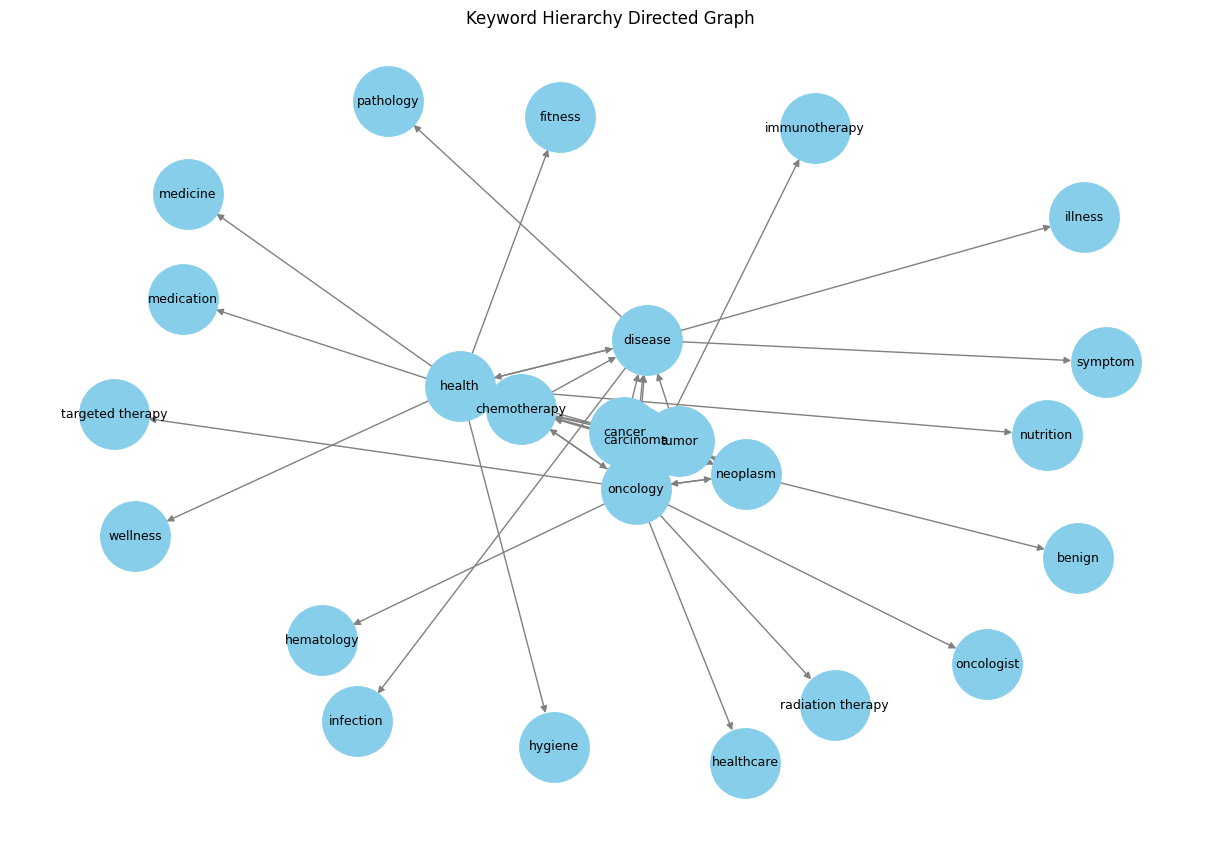

In [33]:

import networkx as nx
import matplotlib.pyplot as plt


G = nx.DiGraph()


for _, row in df.dropna(subset=['parent']).iterrows():
    G.add_edge(row['parent'], row['kwrd'], weight=row['score'])


plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Positions nodes using a spring-force algorithm

nx.draw(G, pos, 
        with_labels=True, 
        node_color='skyblue', 
        node_size=2500, 
        edge_color='gray', 
        font_size=9, 
        arrows=True)

plt.title("Keyword Hierarchy Directed Graph")
plt.show()

In [36]:
import networkx as nx


target_node = 'cancer'
personalization = {node: 0 for node in G.nodes()}
personalization[target_node] = 1  


ppr = nx.pagerank(
    G, 
    alpha=0.85, 
    personalization=personalization, 
    weight='score'
)


sorted_ppr = sorted(ppr.items(), key=lambda x: x[1], reverse=True)

print(f"Top keywords related to {target_node}:")
for node, rank in sorted_ppr[:10]:
    print(f"{node}: {rank:.4f}")

Top keywords related to cancer:
cancer: 0.2925
disease: 0.0910
oncology: 0.0879
carcinoma: 0.0810
tumor: 0.0781
neoplasm: 0.0727
chemotherapy: 0.0684
health: 0.0607
pathology: 0.0155
illness: 0.0155
